---
GridWorld de 2x2

Resolución de Evaluación de Política por Algebra Lineal

(Método de Inversión de Matrices)

---
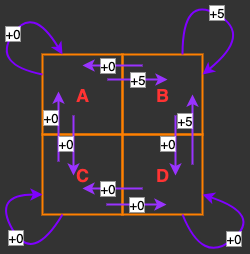

In [2]:
# -*- coding: utf-8 -*-
"""gridworld_2x2_02.ipynb

Automatically generated by Colab.


"""

# =====================================================================
# Algoritmo de Evaluación de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================

import numpy as np
from numpy.linalg import inv

'''
=======================================================================
GridWorld de 2x2 - Resolución de Evaluación de Política por Algebra Lineal
(Método de Inversión de Matrices)
=======================================================================

 ___ ___
|   |   |
| A | B |
|___|___|
|   |   |
| C | D |
|___|___|

Dado un sistema de ecuaciones lineales que puede expresarse en forma matricial
como Ax = b, donde:

    A es la matriz de coeficientes.
    x es el vector de incógnitas (los valores de los estados).
    b es el vector de términos independientes (las recompensas).

A⁻¹ * Ax = A⁻¹ * b
Ix = A⁻¹ * b
x = A⁻¹ * b

Donde I es la matriz identidad.

La solución para x se encuentra multiplicando ambos lados de la ecuación por la
inversa de A (denotada como A⁻¹):

las ecuaciones de Belman a programar son

    V(A) = 1/4 (5 + γ V(B)) + 1/4 (0 + γ V(C)) + 1/2 (0 + γ V(A))

    V(B) = 1/4 (0 + γ V(A)) + 1/4 (0 + γ V(D)) + 1/2 (5 + γ V(B))

    V(C) = 1/4 (0 + γ V(A)) + 1/4 (0 + γ V(D)) + 1/2 (0 + γ V(C))

    V(D) = 1/4 (5 + γ V(B)) + 1/4 (0 + γ V(C)) + 1/2 (0 + γ V(D))

modelando esto en álgebra lineal:

V(A) = (5/4) + (0.7/4)V(B) + (0.7/4)V(C) + (0.7/2)V(A)
V(B) = (5/2) + (0.7/4)V(A) + (0.7/4)V(D) + (0.7/2)V(B)
V(C) = (0.7/4)V(A) + (0.7/4)V(D) + (0.7/2)V(C)
V(D) = (5/4) + (0.7/4)V(B) + (0.7/4)V(C) + (0.7/2)V(D)

los valores se pasan para el otro lado quedando:

V(A) - (0.7/2)V(A) - (0.7/4)V(B) - (0.7/4)V(C) = 5/4
V(B) - (0.7/2)V(B) - (0.7/4)V(A) - (0.7/4)V(D) = 5/2
V(C) - (0.7/2)V(C) - (0.7/4)V(A) - (0.7/4)V(D) = 0
V(D) - (0.7/2)V(D) - (0.7/4)V(B) - (0.7/4)V(C) = 5/4

operando los coeficientes de las variables:

(0.7/2)=0.35
(1-0.35)=0.65
(0.7/4)=0.175

la matriz entonces seria:

(0.65)A +(-0.175)B +(-0.175)C= 5/4
(-0.175)A + (0.65)B +(-0)C +(-0.175)D = 5/2
(-0.175)A +(0)B +(0.65)C+(-0.175)D=0
(0)A +(-0.175)B +(-0.175)C+(0.65)D = 5/4

por lo tanto la matriz de coeficientes es:

[0.65, -0.175, -0.175, 0] para v(A)
[-0.175, 0.65, 0, -0.175] para v(B)
[-0.175, 0, 0.65, -0.175] para v(C)
[0, -0.175, -0.175, 0.65] para v(D)

[5/4] para v(A)
[5/2] para v(B)
[0] para v(C)
[5/4] para v(D)

'''

# Definición de estados
estados = ["A", "B", "C", "D"]

# Factor de Descuento
gamma = 0.7

# Definición de las ecuaciones en forma matricial
# Ax = b, donde x = [V(A), V(B), V(C), V(D)]

# Matriz A: Coeficientes de las variables V(A), V(B), V(C), V(D)
A = np.array([
    [0.65, -0.175, -0.175, 0],  # Ecuación para V(A)
    [-0.175, 0.65, 0, -0.175],  # Ecuación para V(B)
    [-0.175, 0, 0.65, -0.175],  # Ecuación para V(C)
    [0, -0.175, -0.175, 0.65]   # Ecuación para V(D)
])

# Vector b: Términos independientes
b = np.array([
    [5/4],  # Recompensa en el estado A
    [5/2],  # Recompensa en el estado B
    [0],    # Recompensa en el estado C
    [5/4]   # Recompensa en el estado D
])

# Resolver el sistema de ecuaciones Ax = b
x = inv(A).dot(b)

# Imprimir la solución
print("Valores de los estados:")
for i, estado in enumerate(estados):
    print(f"{estado}: {x[i, 0]:.4f}")

Valores de los estados:
A: 4.1667
B: 6.0897
C: 2.2436
D: 4.1667


In [3]:
# -*- coding: utf-8 -*-
"""gridworld_2x2_01.ipynb

Automatically generated by Colab.



# =====================================================================
# Algoritmo de Evaluación de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================
"""

import numpy as np

'''

GridWorld de 2x2 (pseudocodigo)
 ___ ___
|   |   |
| A | B |
|___|___|
|   |   |
| C | D |
|___|___|

=====================================================================
Entrada: π (la política a ser evaluada)
Inicializar un umbral θ > 0 (determina la precisión de la estimación)
Inicializar V(s) ← 0 para todo estado s

Repetir:
    Δ ← 0
    Para cada estado s en S:
        v ← V(s)
        V(s) ← Σ π(a | s) Σ p(s', r | s, a) [r + γ V(s')]
        Δ ← max(Δ, |v - V(s)|)
hasta que Δ < θ
=====================================================================

'''

# Estados
estados = ["A", "B", "C", "D"]

# Factor de Descuento
gamma = 0.7

# Inicialización de Valores de los Estados
valores_estados = {}
for estado in estados:
    valores_estados[estado] = -1

# Umbral de Convergencia
threshold = 0.00001

# Dinamica del Entorno y Politica (Implicita)
def calcular_valor_estado(estado, valores):
    if estado == "A":
        return 1/4 * (5 + gamma * valores["B"]) + 1/4 * (0 + gamma * valores["C"]) + 1/2 * (0 + gamma * valores["A"])
    elif estado == "B":
        return 1/4 * (0 + gamma * valores["A"]) + 1/4 * (0 + gamma * valores["D"]) + 1/2 * (5 + gamma * valores["B"])
    elif estado == "C":
        return 1/4 * (0 + gamma * valores["A"]) + 1/4 * (0 + gamma * valores["D"]) + 1/2 * (0 + gamma * valores["C"])
    elif estado == "D":
        return 1/4 * (5 + gamma * valores["B"]) + 1/4 * (0 + gamma * valores["C"]) + 1/2 * (0 + gamma * valores["D"])
    else:
        return 0  # Estado desconocido


delta = float('inf') # Inicialización de delta con un valor grande
iteration = 0 # Inicialización del contador de iteraciones

while delta > threshold:
    delta = 0 # Diferencia máxima entre iteraciones, para evaluar convergencia
    iteration = iteration + 1
    valores_viejos = valores_estados.copy() # Guarda los valores de la iteración anterior
    for estado in estados:
        nuevo_valor = calcular_valor_estado(estado, valores_viejos) # Calcula el nuevo valor
        valores_estados[estado] = nuevo_valor # Actualiza el valor
        delta = max(delta, abs(nuevo_valor - valores_viejos[estado])) # Calcula la diferencia máxima

    # Imprime los valores en esta iteración
    print(f"Valores en la iteración {iteration}: {valores_estados}")
    print(f"Delta: {delta}")

# Impresión de Resultados Finales
print("\nValores de los estados después de la convergencia:")
for estado, valor in valores_estados.items():
    print(f"{estado}: {valor:.4f}")

Valores en la iteración 1: {'A': 0.5499999999999999, 'B': 1.7999999999999998, 'C': -0.7, 'D': 0.5499999999999999}
Delta: 2.8
Valores en la iteración 2: {'A': 1.6349999999999998, 'B': 3.3225, 'C': -0.05249999999999999, 'D': 1.6349999999999998}
Delta: 1.5225
Valores en la iteración 3: {'A': 2.3945, 'B': 4.235125, 'C': 0.5538749999999999, 'D': 2.3945}
Delta: 0.9126250000000002
Valores en la iteración 4: {'A': 2.92615, 'B': 4.82036875, 'C': 1.03193125, 'D': 2.92615}
Delta: 0.5852437500000001
Valores en la iteración 5: {'A': 3.298305, 'B': 5.2112815625, 'C': 1.3853284374999997, 'D': 3.298305}
Delta: 0.3909128124999999
Valores en la iteración 6: {'A': 3.5588135000000003, 'B': 5.478355296875, 'C': 1.6392717031249997, 'D': 3.5588135000000003}
Delta: 0.2670737343749998
Valores en la iteración 7: {'A': 3.7411694499999997, 'B': 5.663009078906249, 'C': 1.81932982109375, 'D': 3.7411694499999997}
Delta: 0.1846537820312495
Valores en la iteración 8: {'A': 3.8688186149999995, 'B': 5.7914624851171865, 

Valores en la iteración 1: {'alto': 6.8, 'medio': 4.1936, 'bajo': 6.877452800000001}
Valores en la iteración 2: {'alto': 11.981696, 'medio': 9.086408499200001, 'bajo': 11.781110813081602}
Valores en la iteración 3: {'alto': 16.541222899712, 'medio': 13.409464427906663, 'bajo': 15.818172874180082}
Valores en la iteración 4: {'alto': 20.559667559890876, 'medio': 17.130790710968608, 'bajo': 19.246931945001037}
Valores en la iteración 5: {'alto': 24.06930513828977, 'medio': 20.331847035383188, 'bajo': 22.185263729068566}
Valores en la iteración 6: {'alto': 27.116889707414423, 'medio': 23.0890000939508, 'bajo': 24.712358520605402}
Valores en la iteración 7: {'alto': 29.75516047582608, 'medio': 25.46594063102438, 'bajo': 26.889443876096365}
Valores en la iteración 8: {'alto': 32.03552528411486, 'medio': 27.516096951904068, 'bajo': 28.766570681610126}
Valores en la iteración 9: {'alto': 34.00497855610749, 'medio': 29.284838909397685, 'bajo': 30.38575142505546}
Valores en la iteración 10: {'al

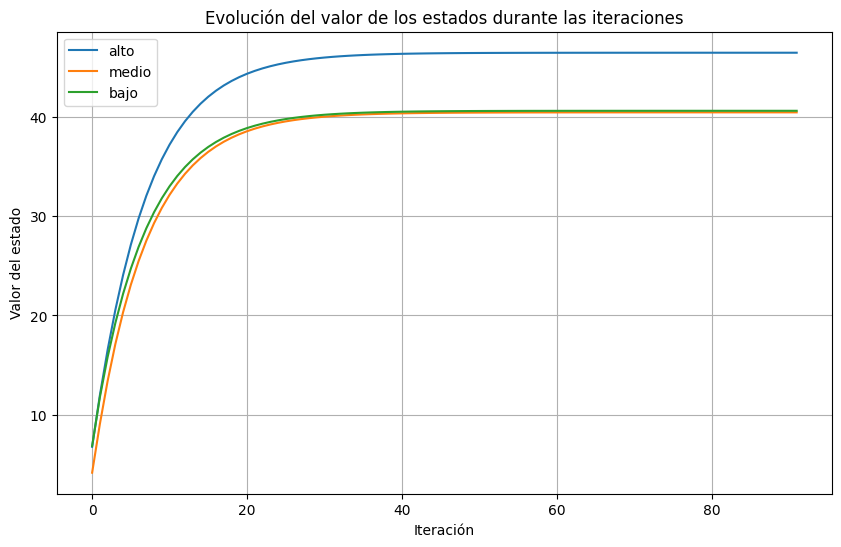

In [ ]:
# -*- coding: utf-8 -*-
"""robot_repositor_01.ipynb

Automatically generated by Colab.


# =====================================================================
# Algoritmo de Evaluación de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================
"""
import numpy as np
import matplotlib.pyplot as plt

'''

Robot repositor (pseudocodigo)

=====================================================================
Entrada: π (la política a ser evaluada)
Inicializar un umbral θ > 0 (determina la precisión de la estimación)
Inicializar V(s) ← 0 para todo estado s

Repetir:
    Δ ← 0
    Para cada estado s en S:
        v ← V(s)
        V(s) ← Σ π(a | s) Σ p(s', r | s, a) [r + γ V(s')]
        Δ ← max(Δ, |v - V(s)|)
hasta que Δ < θ
=====================================================================

'''

# estados y acciones
estados = ["alto", "medio", "bajo"]
acciones = ["reponer", "no reponer"]

# politica (π)
politica = {
    "alto": {"reponer": 0.0, "no reponer": 1.0},
    "medio": {"reponer": 0.4, "no reponer": 0.6},
    "bajo": {"reponer": 0.8, "no reponer": 0.2}
}

# diccionario de recompensas
recompensas = {
    ("alto", "no reponer", "alto"): 8,  # permanecer alto
    ("alto", "no reponer", "medio"): 5, # bajar a medio
    ("medio", "reponer", "alto"): 5,  # subir a alto
    ("medio", "reponer", "medio"): 3, # permanecer medio
    ("medio", "no reponer", "bajo"): 0, # bajar a bajo
    ("medio", "no reponer", "medio"): 3, # permanecer medio
    ("bajo", "reponer", "medio"): 5,  # subir a medio
    ("bajo", "reponer", "bajo"): 2, # permanecer en bajo
    ("bajo", "no reponer", "bajo"): 2 # permanecer en bajo
}

# dinamica del entorno (p(s' | s, a))
def probabilidad_transicion(estado, accion, nuevo_estado):
    if estado == "alto":
        if accion == "no reponer":
            if nuevo_estado == "alto":
                return 0.6  # permanecer alto
            elif nuevo_estado == "medio":
                return 0.4  # bajar a medio
            else:
                return 0
        else:
            return 0 #no deberia haber reponer en estado alto

    elif estado == "medio":
        if accion == "reponer":
            if nuevo_estado == "alto":
                return 0.7  # subir a alto
            elif nuevo_estado == "medio":
                return 0.3  # permanecer medio
            else:
                return 0
        elif accion == "no reponer":
            if nuevo_estado == "bajo":
                return 0.6  # bajar a bajo
            elif nuevo_estado == "medio":
                return 0.4  # permanecer medio
            else:
                return 0

    elif estado == "bajo":
        if accion == "reponer":
            if nuevo_estado == "medio":
                return 0.9  # subir a medio
            elif nuevo_estado == "bajo":
                return 0.1  # permanecer en bajo
            else:
                return 0
        elif accion == "no reponer":
            if nuevo_estado == "bajo":
                return 1.0  # siempre permanece bajo
            else:
                return 0

    return 0  # en caso de que algo no coincida

# factor de descuento
gamma = 0.9

# inicializacion de valores de los estados
valores_estados = {}
for estado in estados:
    valores_estados[estado] = 0

threshold = 0.00001
delta = float('inf')


historial = {} #para poder hacer un grafico cartesiano de la evolucion de v(s)
for estado in estados:
    historial[estado] = []

iteration = 0 # inicializ. del contador de iteraciones

while delta > threshold:
    delta = 0
    iteration = iteration + 1 #  contador de iteraciones
    for estado in estados:
        valor_viejo = valores_estados[estado]
        valor_nuevo = 0

        for accion in acciones:
            v = 0
            for nuevo_estado in estados:
                #aqui se obtiene la recompensa del diccionario
                recompensa = recompensas.get((estado, accion, nuevo_estado), 0) #0 es la recompensa por defecto

                probabilidad = probabilidad_transicion(estado, accion, nuevo_estado)
                v = v + probabilidad * (recompensa + gamma * valores_estados[nuevo_estado])

            valor_nuevo = valor_nuevo + politica[estado][accion] * v

        valores_estados[estado] = valor_nuevo
        delta = max(delta, abs(valor_nuevo - valor_viejo))
        historial[estado].append(valor_nuevo)

    print(f"Valores en la iteración {iteration}: {valores_estados}")

#  resultados finales
print("Valores de los estados:")
for estado, valor in valores_estados.items():
    print(f"{estado}: {valor:.4f}")

# grafico
plt.figure(figsize=(10, 6))
for estado, valores in historial.items():
    plt.plot(valores, label=estado)

plt.xlabel("Iteración")
plt.ylabel("Valor del estado")
plt.title("Evolución del valor de los estados durante las iteraciones")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""gridworld_5x5_01.ipynb

Automatically generated by Colab.



# =====================================================================
# Algoritmo de Evaluación de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================
"""
import numpy as np

'''

GridWorld de 5x5 (pseudocodigo)
 _________
|_|_|_|_|_|
|_|_|_|_|_|
|_|_|_|_|_|
|_|_|_|_|_|
|_|_|_|_|_|

=====================================================================
Entrada: π (la política a ser evaluada)
Inicializar un umbral θ > 0 (determina la precisión de la estimación)
Inicializar V(s) ← 0 para todo estado s

Repetir:
    Δ ← 0
    Para cada estado s en S:
        v ← V(s)
        V(s) ← Σ π(a | s) Σ p(s', r | s, a) [r + γ V(s')]
        Δ ← max(Δ, |v - V(s)|)
hasta que Δ < θ
=====================================================================

'''

# parametros
gamma = 0.9  # factor de descuento
theta = 1e-4  # umbral de convergencia
grid_size = 5  # tamanio del Gridworld
actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]  # Este, Oeste, Norte, Sur

# estados especiales con transiciones forzadas
special_states = {
    (0, 1): ((4, 1), 10),  # Estado A va a A' con +10
    (0, 3): ((2, 3), 5),   # Estado B va a B' con +5
}

V = np.zeros((grid_size, grid_size)) # inicializacion del valor del estado en cero

# iteraciones hasta convergencia
while True:
    delta = 0 # diferencia máxima entre iteraciones, para evaluar convergencia
    new_V = np.copy(V) # copia del valor del estado (en cero al inicio)

    for i in range(grid_size):
        for j in range(grid_size):
            # si el estado es especial, aplicar su transición forzada a A' o B'
            if (i, j) in special_states:
                new_V[i, j] = special_states[(i, j)][1] + gamma * V[special_states[(i, j)][0]]
                continue

            v = 0
            for action in actions:
                ni, nj = i + action[0], j + action[1]
                if 0 <= ni < grid_size and 0 <= nj < grid_size:
                    reward = 0 # movimientos normales sin recompensa
                    v += 0.25 * (reward + gamma * V[ni, nj])
                else:
                    v += 0.25 * (-1 + gamma * V[i, j])  # penalizacion de -1 al chocar con el borde

            new_V[i, j] = v # actualizacion del valor del estado
            delta = max(delta, abs(V[i, j] - new_V[i, j])) # calculo del cambio máximo entre iteraciones

    V = new_V
    if delta < theta:
        break

print("Gridworld Value Function:")
print(V)

Gridworld Value Function:
[[ 3.30980243  8.7900937   4.42841203  5.32315186  1.49295771]
 [ 1.52239365  2.99311872  2.25093263  1.9083562   0.54818211]
 [ 0.05162778  0.73897122  0.67390616  0.35897136 -0.40236082]
 [-0.97278698 -0.43469464 -0.35408886 -0.5848191  -1.18229369]
 [-1.8568951  -1.34443025 -1.22847345 -1.42213156 -1.97439694]]


In [1]:
# -*- coding: utf-8 -*-
"""robot_pasillo_01.ipynb

Automatically generated by Colab.


"""

# =====================================================================
# Algoritmo de Iteración de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================


'''

Robot limpiador de un pasillo
 _______
|_|_|_|_|

'''

import numpy as np

# Definición del entorno
NUM_ESTADOS = 4
ACCIONES = ['Izquierda', 'Derecha']
RECOMPENSA_NORMAL = -1
RECOMPENSA_TERMINAL = 0
FACTOR_DESCUENTO = 0.9

def transicion(estado, accion):
    """Determina el siguiente estado dado el estado actual y la acción."""
    if estado == 4:
        return 4  # En el estado terminal, permanece ahí
    if accion == 'Izquierda':
        return max(1, estado - 1)  # No puede ir a la izquierda desde el estado 1
    elif accion == 'Derecha':
        return min(NUM_ESTADOS, estado + 1) # No puede ir a la derecha desde el estado 4
    else:
        raise ValueError("Acción inválida")

def recompensa(estado, accion):
    """Retorna la recompensa para un estado y acción dados."""
    if estado == 4:
        return RECOMPENSA_TERMINAL
    else:
        return RECOMPENSA_NORMAL

def evaluacion_politica(politica, funcion_valor, tolerancia=1e-6):
    """Evalúa la política actual para determinar la función de valor."""
    iteraciones = 0
    while True:
        delta = 0
        iteraciones += 1
        funcion_valor_anterior = funcion_valor.copy() # Guarda la función de valor de la iteración anterior
        for estado in range(1, NUM_ESTADOS + 1):
            if estado == 4:
                continue  # No necesitamos evaluar el estado terminal
            accion = politica[estado - 1] # Ajuste de índice
            valor_anterior = funcion_valor[estado - 1] # Ajuste de índice

            siguiente_estado = transicion(estado, accion)
            recompensa_inmediata = recompensa(estado, accion)

            funcion_valor[estado - 1] = recompensa_inmediata + FACTOR_DESCUENTO * funcion_valor[siguiente_estado - 1] # Ajuste de índice
            delta = max(delta, abs(valor_anterior - funcion_valor[estado - 1]))

        if iteraciones <= 2:  # Imprime las primeras dos iteraciones
            print(f"    Evaluación Política - Iteración {iteraciones}: {funcion_valor}")

        if delta < tolerancia:
            break

    return funcion_valor

def mejora_politica(funcion_valor):
    """Mejora la política basada en la función de valor actual."""
    politica_estable = True
    nueva_politica = [None] * NUM_ESTADOS # Prealocamos la lista
    for estado in range(1, NUM_ESTADOS + 1):
        if estado == 4:
            nueva_politica[estado - 1] = None # Estado terminal
            continue

        valor_acciones = []
        for accion in ACCIONES:
            siguiente_estado = transicion(estado, accion)
            recompensa_inmediata = recompensa(estado, accion)
            valor_acciones.append(recompensa_inmediata + FACTOR_DESCUENTO * funcion_valor[siguiente_estado - 1])

        mejor_accion_indice = np.argmax(valor_acciones)
        mejor_accion = ACCIONES[mejor_accion_indice]

        if politica[estado - 1] != mejor_accion:
            politica_estable = False
        nueva_politica[estado - 1] = mejor_accion # Ajuste de índice

    return nueva_politica, politica_estable

# Inicialización
politica = ['Derecha', 'Izquierda', 'Derecha', None] # Política inicial (lista, no numpy array para facilitar el uso de strings)
funcion_valor = np.zeros(NUM_ESTADOS) # Función de valor inicial (numpy array para cálculos eficientes)


# Iteración de políticas
iteracion = 0
while True:
    iteracion = iteracion+1
    print(f"Iteración {iteracion}:")

    # 1. Evaluación de la política
    print("  Evaluación de la Política:")
    funcion_valor = evaluacion_politica(politica, funcion_valor)
    print("  Función de valor:", funcion_valor) # Imprime la función de valor después de la convergencia

    # 2. Mejora de la política
    nueva_politica, politica_estable = mejora_politica(funcion_valor)
    print("  Política:", politica)

    if politica_estable:
        print("\nPolítica óptima encontrada:")
        print("  Política:", politica)
        print("  Función de valor:", funcion_valor)
        break

    politica = nueva_politica[:] # Crea una copia para evitar problemas de referencia

Iteración 1:
  Evaluación de la Política:
    Evaluación Política - Iteración 1: [-1.  -1.9 -1.   0. ]
    Evaluación Política - Iteración 2: [-2.71  -3.439 -1.     0.   ]
  Función de valor: [-9.99999647 -9.99999682 -1.          0.        ]
  Política: ['Derecha', 'Izquierda', 'Derecha', None]
Iteración 2:
  Evaluación de la Política:
    Evaluación Política - Iteración 1: [-9.99999682 -1.9        -1.          0.        ]
    Evaluación Política - Iteración 2: [-9.99999714 -1.9        -1.          0.        ]
  Función de valor: [-9.99999714 -1.9        -1.          0.        ]
  Política: ['Izquierda', 'Derecha', 'Derecha', None]
Iteración 3:
  Evaluación de la Política:
    Evaluación Política - Iteración 1: [-2.71 -1.9  -1.    0.  ]
    Evaluación Política - Iteración 2: [-2.71 -1.9  -1.    0.  ]
  Función de valor: [-2.71 -1.9  -1.    0.  ]
  Política: ['Derecha', 'Derecha', 'Derecha', None]

Política óptima encontrada:
  Política: ['Derecha', 'Derecha', 'Derecha', None]
  Función

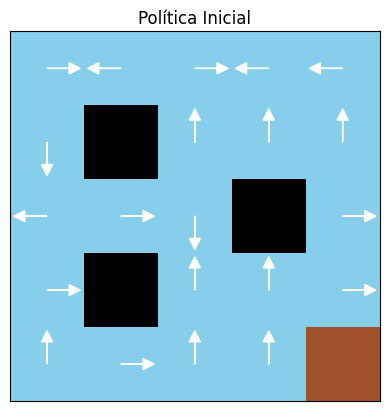

Iteración 1: Delta = 1.0
[-1. -1. -1. -1. -1.]
[-1.  0. -1. -1. -1.]
[-1. -1. -1.  0. -1.]
[-1.  0. -1. -1. -1.]
[-1. -1. -1. -1.  0.]
Iteración 2: Delta = 0.8999999999999999
[-1.9 -1.9 -1.9 -1.9 -1.9]
[-1.9  0.  -1.9 -1.9 -1.9]
[-1.9 -1.9 -1.9  0.  -1.9]
[-1.9  0.  -1.9 -1.9 -1. ]
[-1.9 -1.9 -1.9 -1.   0. ]
Iteración 3: Delta = 0.81
[-2.71 -2.71 -2.71 -2.71 -2.71]
[-2.71  0.   -2.71 -2.71 -2.71]
[-2.71 -2.71 -2.71  0.   -1.9 ]
[-2.71  0.   -2.71 -1.9  -1.  ]
[-2.71 -2.71 -1.9  -1.    0.  ]
Iteración 4: Delta = 0.7290000000000001
[-3.439 -3.439 -3.439 -3.439 -3.439]
[-3.439  0.    -3.439 -3.439 -2.71 ]
[-3.439 -3.439 -3.439  0.    -1.9  ]
[-3.439  0.    -2.71  -1.9   -1.   ]
[-3.439 -2.71  -1.9   -1.     0.   ]
Iteración 5: Delta = 0.6561000000000003
[-4.0951 -4.0951 -4.0951 -4.0951 -3.439 ]
[-4.0951  0.     -4.0951 -3.439  -2.71  ]
[-4.0951 -4.0951 -3.439   0.     -1.9   ]
[-4.0951  0.     -2.71   -1.9    -1.    ]
[-3.439 -2.71  -1.9   -1.     0.   ]
Iteración 6: Delta = 0.59049
[-4.6

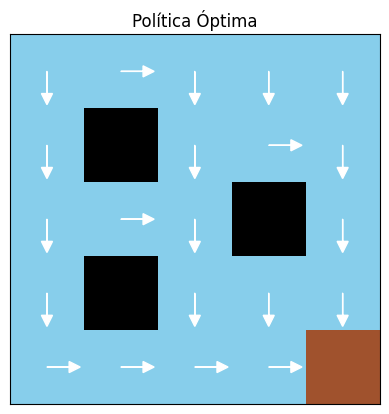


Política Óptima:
(0, 0): Sur  (0, 1): Este  (0, 2): Sur  (0, 3): Sur  (0, 4): Sur  
(1, 0): Sur  (1, 1): Roca  (1, 2): Sur  (1, 3): Este  (1, 4): Sur  
(2, 0): Sur  (2, 1): Este  (2, 2): Sur  (2, 3): Roca  (2, 4): Sur  
(3, 0): Sur  (3, 1): Roca  (3, 2): Sur  (3, 3): Sur  (3, 4): Sur  
(4, 0): Este  (4, 1): Este  (4, 2): Este  (4, 3): Este  (4, 4): Muelle  


In [5]:
# -*- coding: utf-8 -*-
"""barco_en_oceano.ipynb

Automatically generated by Colab.


"""

# =====================================================================
# Algoritmo de Iteración de Valor
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================


'''

Navegación de un barco en un oceano de 5x5
 _________
|_|_|_|_|_|
|_|■|_|_|_|
|_|_|_|■|_|
|_|■|_|_|_|
|_|_|_|_|□|<--Muelle en (4,4)

■ rocas o islotes
□ muelle (destino)

'''

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# definición del Entorno
LADO_OCEANO = 5  # Tamaño del oceano (cuadrado de 5x5)
MUELLE = (4, 4)  # Coordenadas del muelle (fila, columna)
ROCAS = [(1, 1), (2, 3), (3, 1)]  # Coordenadas de las rocas
ACCIONES = ['Norte', 'Sur', 'Este', 'Oeste']
RECOMPENSA_MOVIMIENTO = -1
RECOMPENSA_MUELLE = 0
RECOMPENSA_ROCA = -1
FACTOR_DESCUENTO = 0.9
TOLERANCIA = 1e-6


def es_valido(fila, columna):
    """Verifica si una celda está dentro de los límites del oceano."""
    return 0 <= fila < LADO_OCEANO and 0 <= columna < LADO_OCEANO


def es_roca(fila, columna):
    """Verifica si una celda contiene una roca."""
    return (fila, columna) in ROCAS


def transicion(fila, columna, accion):
    """Determina el siguiente estado (celda) dado el estado actual y la acción."""
    if (fila, columna) == MUELLE:
        return MUELLE  # si ya está en el muelle, se queda ahí

    if accion == 'Norte':
        nueva_fila, nueva_columna = fila - 1, columna
    elif accion == 'Sur':
        nueva_fila, nueva_columna = fila + 1, columna
    elif accion == 'Este':
        nueva_fila, nueva_columna = fila, columna + 1
    elif accion == 'Oeste':
        nueva_fila, nueva_columna = fila, columna - 1
    else:
        raise ValueError("Acción inválida")

    if not es_valido(nueva_fila, nueva_columna) or es_roca(nueva_fila, nueva_columna):
        return fila, columna  # permanece en la misma celda si el movimiento no es válido

    return nueva_fila, nueva_columna


def recompensa(fila, columna, accion):
    """Retorna la recompensa para un estado (celda) y acción dados."""
    if (fila, columna) == MUELLE:
        return RECOMPENSA_MUELLE
    nueva_fila, nueva_columna = transicion(fila, columna, accion)
    if es_roca(nueva_fila, nueva_columna):
        return RECOMPENSA_ROCA  # penalizacion por intentar ir a una roca
    return RECOMPENSA_MOVIMIENTO


def dibujar_entorno(politica, titulo):
    """Dibuja el entorno del oceano con las rocas, el muelle y las acciones."""
    mapa = np.zeros((LADO_OCEANO, LADO_OCEANO))  # 0: agua, 1: roca, 2: muelle
    for fila, columna in ROCAS:
        mapa[fila, columna] = 1
    mapa[MUELLE] = 2

    # colores personalizados
    cmap = ListedColormap(['skyblue', 'black', 'sienna'])
    plt.imshow(mapa, cmap=cmap, origin='lower')

    # inversion del eje para que coincida con las coordenadas de la matriz
    plt.gca().invert_yaxis()

    # agrega las flechas de la politica
    for fila in range(LADO_OCEANO):
        for columna in range(LADO_OCEANO):
            if (fila, columna) not in ROCAS and (fila, columna) != MUELLE:
                accion = politica[(fila, columna)]
                dx, dy = 0, 0
                if accion == 'Norte':
                    dy = -0.3  # inversion dy para el eje y invertido
                elif accion == 'Sur':
                    dy = 0.3  # inversion dy para el eje y invertido
                elif accion == 'Este':
                    dx = 0.3
                elif accion == 'Oeste':
                    dx = -0.3
                plt.arrow(columna, fila, dx, dy, head_width=0.15, head_length=0.15, fc='white', ec='white')  # Flechas más pequeñas

    plt.title(titulo)
    plt.xticks([])
    plt.yticks([])
    #plt.show()
    return plt  # devuelve el objeto plt para guardarlo o mostrarlo más tarde


# inicializacion de la función de valor
funcion_valor = np.zeros((LADO_OCEANO, LADO_OCEANO))
funcion_valor[MUELLE] = 0  # el muelle tiene valor 0

# politica inicial (aleatoria)
politica_inicial = {}
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        if (fila, columna) not in ROCAS and (fila, columna) != MUELLE:
            politica_inicial[(fila, columna)] = np.random.choice(ACCIONES)
        else:
            politica_inicial[(fila, columna)] = None  # Roca o Muelle

#  entorno con la política inicial
plt_inicial = dibujar_entorno(politica_inicial, "Política Inicial")
plt_inicial.show() # muestra el grafico inicial

# algoritmo de iteracion de valor
iteracion = 0
while True:
    iteracion += 1
    delta = 0  # para verificar la convergencia

    # copia de la nueva finco de valor v(s)
    funcion_valor_anterior = funcion_valor.copy()

    for fila in range(LADO_OCEANO):
        for columna in range(LADO_OCEANO):
            if es_roca(fila, columna):
                continue  # no se actualizan las rocas
            if (fila, columna) == MUELLE:
                continue # no actualiza el valor del muelle
            # aqui se calcula el valor de cada celda con la ecuación de Bellman
            valores_acciones = []
            for accion in ACCIONES:
                nueva_fila, nueva_columna = transicion(fila, columna, accion) # transicion me devuelve la nueva posicion de barco (nuevo estado)
                recompensa_inmediata = recompensa(fila, columna, accion) # recompensa devuelve 0: muelle, -1: avance, -100:colision con roca
                valores_acciones.append(recompensa_inmediata + FACTOR_DESCUENTO * funcion_valor[nueva_fila, nueva_columna]) # ecuacion de bellman

            funcion_valor[fila, columna] = max(valores_acciones)
            delta = max(delta, abs(funcion_valor[fila, columna] - funcion_valor_anterior[fila, columna]))

    print(f"Iteración {iteracion}: Delta = {delta}")
    # impresion poe consola del valor de cada celda en formato matricial
    for i in range(LADO_OCEANO):
        print(funcion_valor[i,:])
    if delta < TOLERANCIA:
        break

# extraccion de la politica optima
politica_optima = {}
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        if es_roca(fila, columna):
            politica_optima[(fila, columna)] = "Roca" # las rocas no tienen política
            continue
        if (fila, columna) == MUELLE:
            politica_optima[(fila, columna)] = "Muelle"
            continue
        # calculo del valor de cada acción para encontrar la mejor
        valores_acciones = []
        for accion in ACCIONES:
            nueva_fila, nueva_columna = transicion(fila, columna, accion)
            recompensa_inmediata = recompensa(fila, columna, accion)
            valores_acciones.append(recompensa_inmediata + FACTOR_DESCUENTO * funcion_valor[nueva_fila, nueva_columna])

        mejor_accion_indice = np.argmax(valores_acciones)
        politica_optima[(fila, columna)] = ACCIONES[mejor_accion_indice]

# grafico del entorno con la politica óptima
plt_optima = dibujar_entorno(politica_optima, "Política Óptima")
plt_optima.show() # muestra el gráfico final

# impresion por consola de la poltica optima
print("\nPolítica Óptima:")
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        print(f"({fila}, {columna}): {politica_optima[(fila, columna)]}", end="  ")
    print()